In [68]:
print("Skin Disease Model Training")

Skin Disease Model Training


In [69]:
# import libraries

import os
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib as pl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import seaborn as sns
import sklearn as skl
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report , roc_auc_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization , GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model


In [70]:
# check version of all libraries
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", pl.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", skl.__version__)
print("TensorFlow version:", tf.__version__)


Pandas version: 2.3.3
NumPy version: 1.23.5
Matplotlib version: 3.9.4
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
TensorFlow version: 2.10.0


In [71]:
# check gpu availibility 

print("Available devices:", tf.config.list_physical_devices())

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [72]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 20689135279629076
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 2967715840
locality {
  bus_id: 1
  links {
  }
}
incarnation: 3861994467071329468
physical_device_desc: "device: 0, name: NVIDIA GeForce 940MX, pci bus id: 0000:01:00.0, compute capability: 5.0"
xla_global_id: 416903419
]


In [73]:
# load dataset

# Path of dataset
dataset_path = "IMG_CLASSES"

In [74]:


# Original folder names
original_names = [
    "1. Eczema 1677",
    "2. Melanoma 15.75k",
    "3. Atopic Dermatitis - 1.25k",
    "4. Basal Cell Carcinoma (BCC) 3323",
    "5. Melanocytic Nevi (NV) - 7970",
    "6. Benign Keratosis-like Lesions (BKL) 2624",
    "7. Psoriasis pictures Lichen Planus and related diseases - 2k",
    "8. Seborrheic Keratoses and other Benign Tumors - 1.8k",
    "9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k",
    "10. Warts Molluscum and other Viral Infections - 2103"
]

In [75]:

# Cleaned folder names
cleaned_names = [
    "Eczema",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma (BCC)",
    "Melanocytic Nevi (NV)",
    "Benign Keratosis-like Lesions (BKL)",
    "Psoriasis and Related Diseases",
    "Seborrheic Keratoses and Benign Tumors",
    "Fungal Infections (Tinea, Ringworm, Candidiasis)",
    "Viral Infections (Warts, Molluscum)"
]



In [76]:

# Rename folders
for old, new in zip(original_names, cleaned_names):
    old_path = os.path.join(dataset_path, old)
    new_path = os.path.join(dataset_path, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {old} → {new}")
    else:
        print(f"Not found: {old}")

Not found: 1. Eczema 1677
Not found: 2. Melanoma 15.75k
Not found: 3. Atopic Dermatitis - 1.25k
Not found: 4. Basal Cell Carcinoma (BCC) 3323
Not found: 5. Melanocytic Nevi (NV) - 7970
Not found: 6. Benign Keratosis-like Lesions (BKL) 2624
Not found: 7. Psoriasis pictures Lichen Planus and related diseases - 2k
Not found: 8. Seborrheic Keratoses and other Benign Tumors - 1.8k
Not found: 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
Not found: 10. Warts Molluscum and other Viral Infections - 2103


In [77]:
# load dataset into df 

data = []
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                data.append({
                    "class": class_name,
                    "image_path": os.path.join(class_path, img_file)
                })

df = pd.DataFrame(data)


In [78]:
df.head()

,class,image_path
0,Atopic Dermatitis,IMG_CLASSES\Atopic Dermatitis\0_0.jpg
1,Atopic Dermatitis,IMG_CLASSES\Atopic Dermatitis\0_1.jpg
2,Atopic Dermatitis,IMG_CLASSES\Atopic Dermatitis\0_10.jpg
3,Atopic Dermatitis,IMG_CLASSES\Atopic Dermatitis\0_11.jpg
4,Atopic Dermatitis,IMG_CLASSES\Atopic Dermatitis\0_12.jpg


In [79]:
df["class"].unique()

array(['Atopic Dermatitis', 'Basal Cell Carcinoma (BCC)',
       'Benign Keratosis-like Lesions (BKL)', 'Eczema',
       'Fungal Infections (Tinea, Ringworm, Candidiasis)',
       'Melanocytic Nevi (NV)', 'Melanoma',
       'Psoriasis and Related Diseases',
       'Seborrheic Keratoses and Benign Tumors',
       'Viral Infections (Warts, Molluscum)'], dtype=object)

In [80]:
class_counts = df['class'].value_counts()
class_counts

class
Fungal Infections (Tinea, Ringworm, Candidiasis)    7026
Seborrheic Keratoses and Benign Tumors              7025
Basal Cell Carcinoma (BCC)                          7021
Viral Infections (Warts, Molluscum)                 7018
Melanoma                                            7015
Psoriasis and Related Diseases                      7011
Eczema                                              7008
Atopic Dermatitis                                   7004
Benign Keratosis-like Lesions (BKL)                 7003
Melanocytic Nevi (NV)                               7000
Name: count, dtype: int64

In [81]:
classes = class_counts.index.tolist()
classes

['Fungal Infections (Tinea, Ringworm, Candidiasis)',
 'Seborrheic Keratoses and Benign Tumors',
 'Basal Cell Carcinoma (BCC)',
 'Viral Infections (Warts, Molluscum)',
 'Melanoma',
 'Psoriasis and Related Diseases',
 'Eczema',
 'Atopic Dermatitis',
 'Benign Keratosis-like Lesions (BKL)',
 'Melanocytic Nevi (NV)']

In [82]:
counts = class_counts.values.tolist()
counts

[7026, 7025, 7021, 7018, 7015, 7011, 7008, 7004, 7003, 7000]

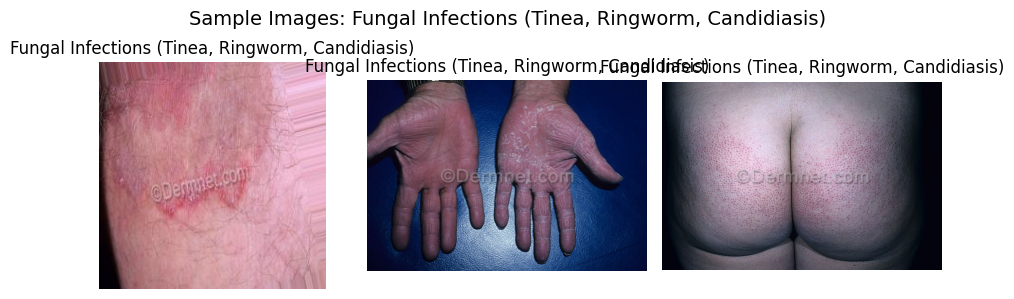

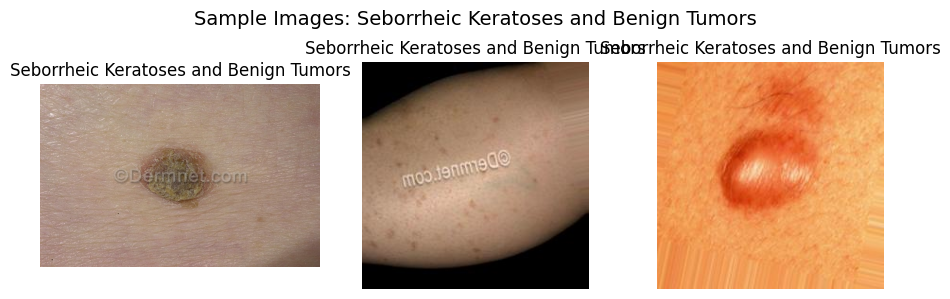

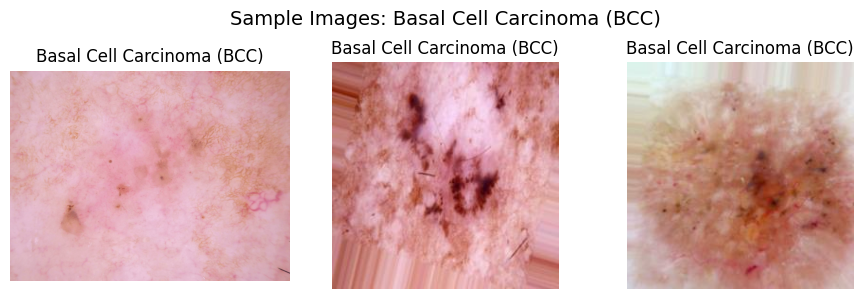

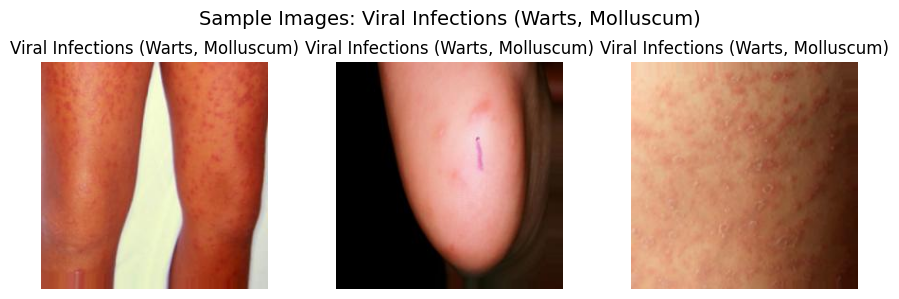

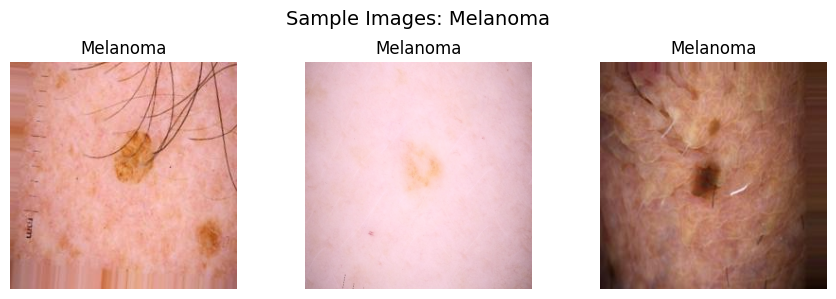

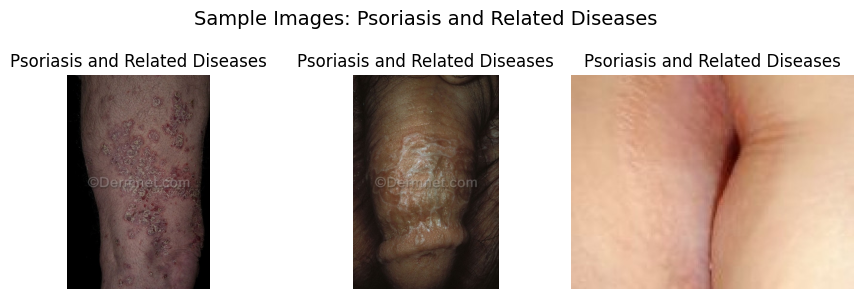

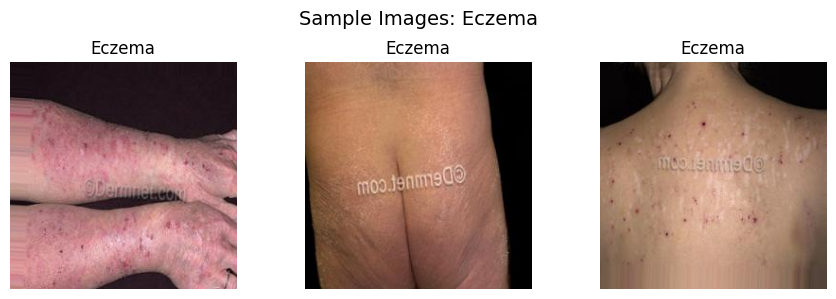

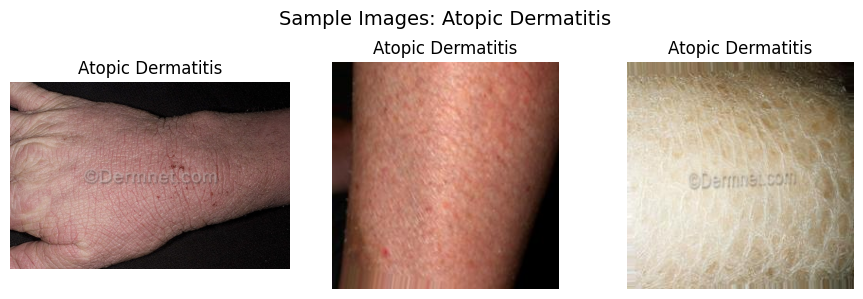

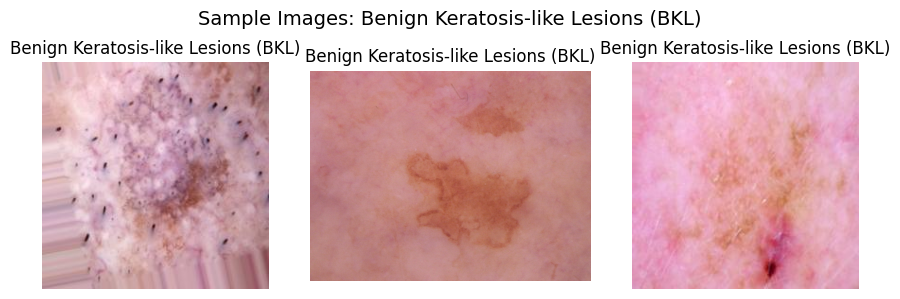

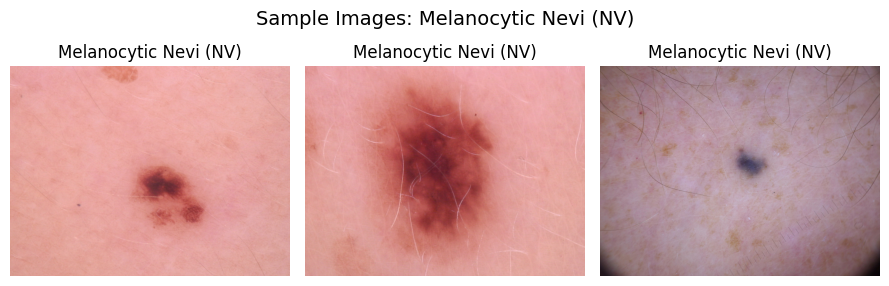

In [83]:
# Step 4: Show 3 sample images per class
for class_name in classes:
    sample_images = df[df['class'] == class_name].sample(n=3, random_state=42)['image_path'].tolist()
    plt.figure(figsize=(9, 3))
    for i, img_path in enumerate(sample_images):
        img = mpimg.imread(img_path)
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.suptitle(f"Sample Images: {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


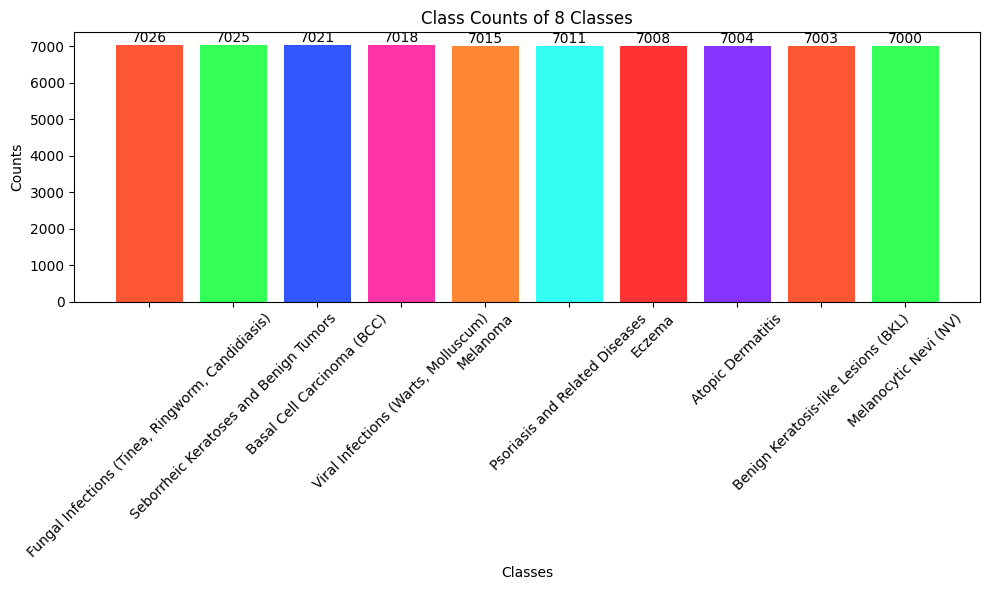

In [84]:
# Step 3: Plot class counts
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts of 8 Classes')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [85]:
target_count = 7000
# Define image size and batch size
img_size = (256, 256)
batch_size = 32


In [86]:
def balance_dataset(data_path, target=7000):
    datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
    )

    for class_name in os.listdir(data_path):
        class_dir = os.path.join(data_path, class_name)
        if not os.path.isdir(class_dir): continue
        
        images = [img for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        current_count = len(images)
        
        # CASE 1: UNDERSAMPLING
        if current_count > target:
            num_to_delete = current_count - target
            to_delete = random.sample(images, num_to_delete)
            for img in to_delete:
                os.remove(os.path.join(class_dir, img))
            print(f"✂️ Undersampled {class_name}: Removed {num_to_delete} images.")

        # CASE 2: OVERSAMPLING
        elif current_count < target:
            print(f"🔄 Oversampling {class_name}...")
            diff = target - current_count
            while current_count < target:
                batch_files = random.sample(images, min(batch_size, len(images)))
                batch_imgs = [np.array(Image.open(os.path.join(class_dir, f)).convert('RGB').resize((240, 240))) for f in batch_files]
                
                # Generate and save
                for _ in datagen.flow(np.array(batch_imgs), batch_size=len(batch_imgs),
                                     save_to_dir=class_dir, save_prefix='aug', save_format='jpg'):
                    current_count += len(batch_imgs)
                    break
            print(f"✅ Balanced {class_name} to {current_count} images.")



In [87]:
balance_dataset(dataset_path, target=target_count)

✂️ Undersampled Atopic Dermatitis: Removed 4 images.
✂️ Undersampled Basal Cell Carcinoma (BCC): Removed 21 images.
✂️ Undersampled Benign Keratosis-like Lesions (BKL): Removed 3 images.
✂️ Undersampled Eczema: Removed 8 images.
✂️ Undersampled Fungal Infections (Tinea, Ringworm, Candidiasis): Removed 26 images.
✂️ Undersampled Melanoma: Removed 15 images.
✂️ Undersampled Psoriasis and Related Diseases: Removed 11 images.
✂️ Undersampled Seborrheic Keratoses and Benign Tumors: Removed 25 images.
✂️ Undersampled Viral Infections (Warts, Molluscum): Removed 18 images.


In [88]:
# Re-check class counts after oversampling

data_after = []
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                data_after.append({
                    "class": class_name,
                    "image_path": os.path.join(class_path, img_file)
                })

df_after = pd.DataFrame(data_after)


In [89]:
class_counts_after = df_after['class'].value_counts()

In [90]:

print("\n Class counts after oversampling:\n")
print(class_counts_after)



 Class counts after oversampling:

class
Atopic Dermatitis                                   7000
Basal Cell Carcinoma (BCC)                          7000
Benign Keratosis-like Lesions (BKL)                 7000
Eczema                                              7000
Fungal Infections (Tinea, Ringworm, Candidiasis)    7000
Melanocytic Nevi (NV)                               7000
Melanoma                                            7000
Psoriasis and Related Diseases                      7000
Seborrheic Keratoses and Benign Tumors              7000
Viral Infections (Warts, Molluscum)                 7000
Name: count, dtype: int64


In [91]:
classes_after = class_counts_after.index.tolist()
counts_after = class_counts_after.values.tolist()

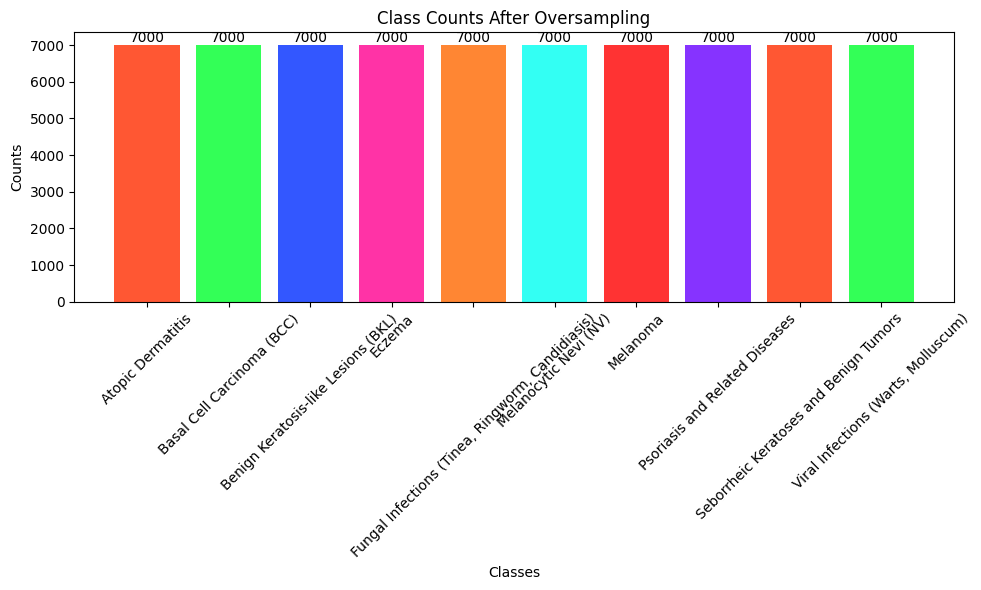

In [92]:
plt.figure(figsize=(10, 6))
bars = plt.bar(classes_after, counts_after, color=[
    '#FF5733', '#33FF57', '#3357FF', '#FF33A6',
    '#FF8633', '#33FFF3', '#FF3333', '#8633FF'
])
plt.xlabel('Classes')
plt.ylabel('Counts')
plt.title('Class Counts After Oversampling')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [93]:
# Paths for training, validation, and testing datasets
train_path = "train"
val_path = "val"
test_path = "test"

In [94]:
# Create directories for each dataset split
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

In [95]:
# Ratios
train_ratio, val_ratio, test_ratio = 0.8, 0.1, 0.1

In [96]:
# Loop over each folder (class) in IMG_CLASSES
for folder in os.listdir(dataset_path):   # dataset_path = "IMG_CLASSES"
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    
    # Create subfolders inside train/val/test
    train_class_path = os.path.join(train_path, folder)
    val_class_path = os.path.join(val_path, folder)
    test_class_path = os.path.join(test_path, folder)
    
    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(val_class_path, exist_ok=True)
    os.makedirs(test_class_path, exist_ok=True)
    
    # List and shuffle images
    images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)
    num_images = len(images)
    
    # Split counts
    num_train = int(num_images * train_ratio)
    num_val = int(num_images * val_ratio)
    num_test = num_images - num_train - num_val
    
    # Allocate images
    train_images = images[:num_train]
    val_images = images[num_train:num_train + num_val]
    test_images = images[num_train + num_val:]
    
    # Copy images
    for img in train_images:
        shutil.copy(os.path.join(folder_path, img), os.path.join(train_class_path, img))
    for img in val_images:
        shutil.copy(os.path.join(folder_path, img), os.path.join(val_class_path, img))
    for img in test_images:
        shutil.copy(os.path.join(folder_path, img), os.path.join(test_class_path, img))
    
    print(f"Split completed for {folder}: Train={len(train_images)}, Val={len(val_images)}, Test={len(test_images)}")

print("\n Dataset split completed successfully.")


Split completed for Atopic Dermatitis: Train=5600, Val=700, Test=700
Split completed for Basal Cell Carcinoma (BCC): Train=5600, Val=700, Test=700
Split completed for Benign Keratosis-like Lesions (BKL): Train=5600, Val=700, Test=700
Split completed for Eczema: Train=5600, Val=700, Test=700
Split completed for Fungal Infections (Tinea, Ringworm, Candidiasis): Train=5600, Val=700, Test=700
Split completed for Melanocytic Nevi (NV): Train=5600, Val=700, Test=700
Split completed for Melanoma: Train=5600, Val=700, Test=700
Split completed for Psoriasis and Related Diseases: Train=5600, Val=700, Test=700
Split completed for Seborrheic Keratoses and Benign Tumors: Train=5600, Val=700, Test=700
Split completed for Viral Infections (Warts, Molluscum): Train=5600, Val=700, Test=700

 Dataset split completed successfully.


In [97]:

# Function to count images in a dataset split
def count_images(split_path):
    total = 0
    for folder in os.listdir(split_path):
        folder_path = os.path.join(split_path, folder)
        if os.path.isdir(folder_path):
            total += len([img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

# Count images in each split
train_count = count_images(train_path)
val_count   = count_images(val_path)
test_count  = count_images(test_path)

# Print results
print(f"Train images: {train_count}")
print(f"Validation images: {val_count}")
print(f"Test images: {test_count}")
print(f"\n Total images (Train + Val + Test): {train_count + val_count + test_count}")


Train images: 70320
Validation images: 19076
Test images: 19075

 Total images (Train + Val + Test): 108471


In [98]:
# Paths to train and validation datasets that i created above
train_path = "train"
val_path = "val"
test_path = "test"

In [99]:
from tensorflow.keras.preprocessing import image_dataset_from_directory


# Create the train dataset
train_dataset = image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=123
)



Found 70320 files belonging to 10 classes.


In [100]:
# Create the validation dataset
val_dataset = image_dataset_from_directory(
    val_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=42
)

Found 19076 files belonging to 10 classes.


In [101]:
# Create the test dataset 
test_dataset = image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    seed=99
)

Found 19075 files belonging to 10 classes.


In [102]:
# Preprocessing for ResNet50 

@tf.function
def preprocess_image(image, label):
    # Resize the image to 224x224 
    image = tf.image.resize(image, [224, 224])
    # Apply ResNet50 preprocessing (Mean subtraction and BGR conversion)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

# We use AUTOTUNE to let TensorFlow optimize CPU usage automatically
train_dataset = train_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image).prefetch(tf.data.AUTOTUNE)

print(" ResNet50 preprocessing applied to Train, Val, and Test datasets.")

 ResNet50 preprocessing applied to Train, Val, and Test datasets.


In [103]:
# ----------------- Base Model -----------------
base_model = ResNet50(
    input_shape=(224, 224, 3),   # Standard ResNet50 input size
    include_top=False,
    weights='imagenet'
)


In [104]:
# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

In [105]:

# ----------------- Custom Classifier -----------------
inputs = base_model.input
x = GlobalAveragePooling2D()(base_model.output)   # Better than Flatten
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)   # Dropout helps against overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)  # Adjust classes




In [106]:
# ----------------- Build Model -----------------
model = Model(inputs=inputs, outputs=outputs)

In [107]:
# Compile (Frozen training)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [108]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_2[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                            

In [109]:

#  Fine-tuning 
# Unfreeze last 50 layers for fine-tuning
for layer in base_model.layers[-50:]:
    layer.trainable = True

In [110]:

# Recompile with smaller learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [111]:

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [112]:

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [113]:

checkpoint = ModelCheckpoint(
    filepath="best_model_checkpoint_2.h5",  # Saved in root
    monitor="val_accuracy",                 
    save_best_only=True,                    
    save_weights_only=False, # Changed to False to save the WHOLE model               
    verbose=1
)


In [ ]:

# Train the model
epochs = 50
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping, lr_reduction, checkpoint]
)


model = load_model("best_model_checkpoint_2.h5")

In [116]:
model_final_name = 'skin_disease_final_model_2.h5'
model.save(model_final_name)

print(f"Model saved successfully in the root directory as: {model_final_name}")


Model saved successfully in the root directory as: skin_disease_final_model_2.h5


In [ ]:
#  Training vs Validation  Results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

In [ ]:
print(f"\n--- Final Training Results ---")
print(f"Training Accuracy:   {final_train_acc:.4f} | Training Loss:   {final_train_loss:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f} | Validation Loss: {final_val_loss:.4f}")


--- Final Training Results ---
Training Accuracy:   0.9925 | Training Loss:   0.0254
Validation Accuracy: 0.9320 | Validation Loss: 0.3163


In [118]:
# 2. EVALUATE ON TEST SET
print("\n--- Evaluating on Test Dataset ---")
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")


--- Evaluating on Test Dataset ---
597/597 [==============================] - 678s 1s/step - loss: 0.0182 - accuracy: 0.9958
Test Accuracy: 0.9958
Test Loss:     0.0182


In [ ]:
# 3. GRAPHS: Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#2ecc71')
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [120]:
y_true = []
y_probs = []

# Data nikaalna
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_probs.extend(model.predict(images, verbose=0))

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = np.argmax(y_probs, axis=1)

In [121]:
# AUC Score
auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
print(f"\nTotal AUC Score: {auc_score:.4f}")


Total AUC Score: 0.9999


In [122]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=cleaned_names))


Classification Report:

                                                  precision    recall  f1-score   support

                                          Eczema       0.99      0.99      0.99      1887
                                        Melanoma       1.00      1.00      1.00      1903
                               Atopic Dermatitis       1.00      1.00      1.00      1892
                      Basal Cell Carcinoma (BCC)       0.99      1.00      0.99      1886
                           Melanocytic Nevi (NV)       1.00      0.99      1.00      1913
             Benign Keratosis-like Lesions (BKL)       1.00      1.00      1.00      1985
                  Psoriasis and Related Diseases       1.00      1.00      1.00      1894
          Seborrheic Keratoses and Benign Tumors       0.99      0.99      0.99      1901
Fungal Infections (Tinea, Ringworm, Candidiasis)       1.00      1.00      1.00      1907
             Viral Infections (Warts, Molluscum)       1.00      0.99     

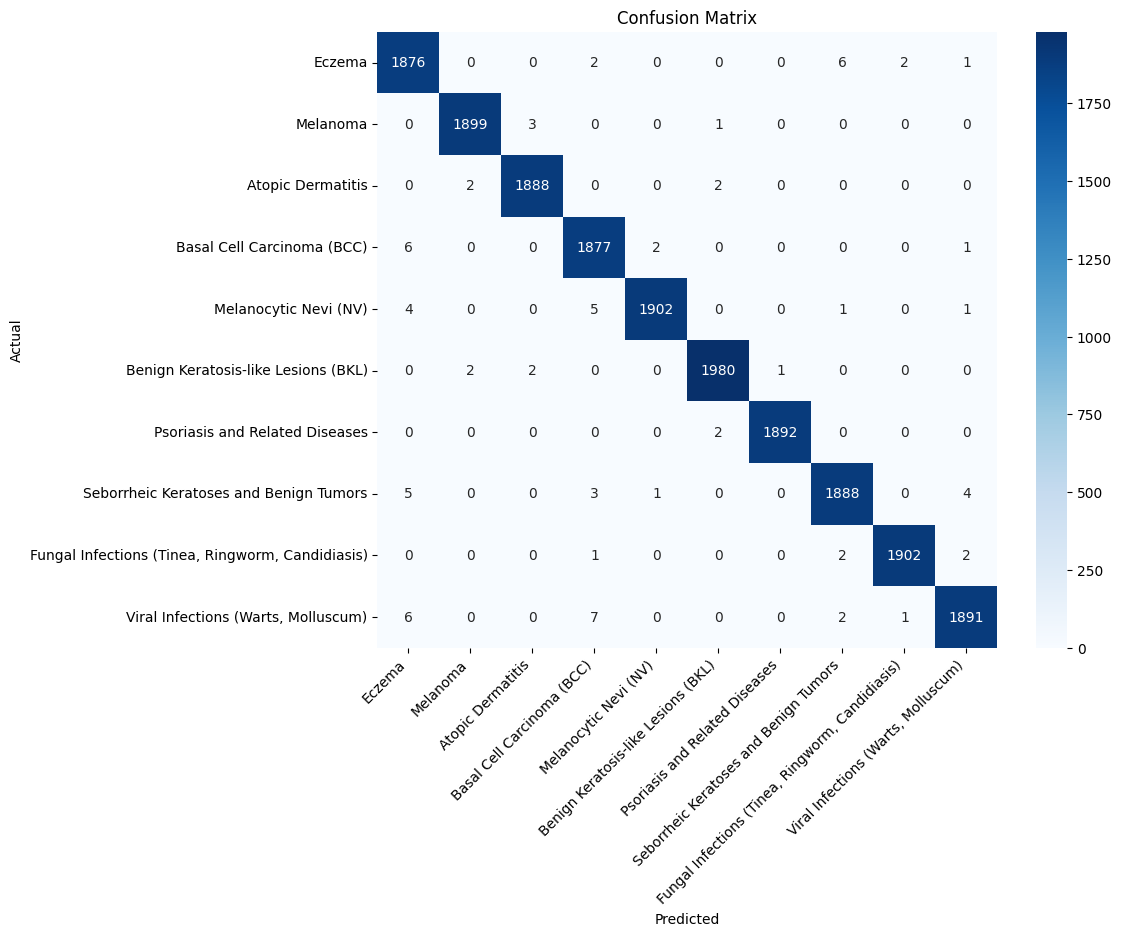

In [123]:
# Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues", 
            xticklabels=cleaned_names, yticklabels=cleaned_names)
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha="right")
plt.show()

In [126]:
# --- EVALUATION KO TEXT FILE MEIN SAVE KARNA ---

report = classification_report(y_true, y_pred, target_names=cleaned_names)

with open("evaluation_results_2.txt", "w") as f:
    f.write("SKIN DISEASE MODEL EVALUATION REPORT\n")
    f.write("="*40 + "\n\n")
    
    # Accuracy and Loss
    # f.write(f"Final Train Accuracy: {final_train_acc:.4f}\n")
    # f.write(f"Final Val Accuracy:   {final_val_acc:.4f}\n")
    f.write(f"Final Test Accuracy:  {test_acc:.4f}\n")
    f.write(f"Final Test Loss:      {test_loss:.4f}\n\n")
    
    # AUC Score
    f.write(f"Total AUC Score (Macro): {auc_score:.4f}\n\n")
    
    # Full Classification Report
    f.write("Detailed Classification Report:\n")
    f.write("-" * 30 + "\n")
    f.write(report)
    f.write("\n" + "="*40 + "\n")
    f.write("Evaluation Completed Successfully.")

print("✅ Sabhi results 'evaluation_results_2.txt' mein save ho gaye hain!")

✅ Sabhi results 'evaluation_results_2.txt' mein save ho gaye hain!


In [127]:

class_names = sorted([f for f in os.listdir("train") if os.path.isdir(os.path.join("train", f))])

print("\n--- Model Class Index Mapping ---")
print(f"{'Index':<10} : {'Class Name'}")
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{i:<10} : {name}")

# Create a dictionary for easy lookups in your prediction functions
index_to_class = {i: name for i, name in enumerate(class_names)}


--- Model Class Index Mapping ---
Index      : Class Name
----------------------------------------
0          : Atopic Dermatitis
1          : Basal Cell Carcinoma (BCC)
2          : Benign Keratosis-like Lesions (BKL)
3          : Eczema
4          : Fungal Infections (Tinea, Ringworm, Candidiasis)
5          : Melanocytic Nevi (NV)
6          : Melanoma
7          : Psoriasis and Related Diseases
8          : Seborrheic Keratoses and Benign Tumors
9          : Viral Infections (Warts, Molluscum)
